Loading and projecting county shapefile...
Precomputing grid-to-county spatial mapping...
Processing monthly timelines from 2015 to 2025...
Generating simplified categorical Hovmöller heatmap...


/tmp/ipykernel_399/2434764451.py:215: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='#EFEFEF', edgecolor='none', label='No HAB Detected / Low (< 10,000)'),
/tmp/ipykernel_399/2434764451.py:216: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='#FFD700', edgecolor='none', label='Medium Concentration (10,000 - 100,000)'),
/tmp/ipykernel_399/2434764451.py:217: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='#D32F2F', edgecolor='none', label='High Concentration (> 100,000)')


Process complete! Clean categorical figure saved as hovmoller_categorical_hab.png


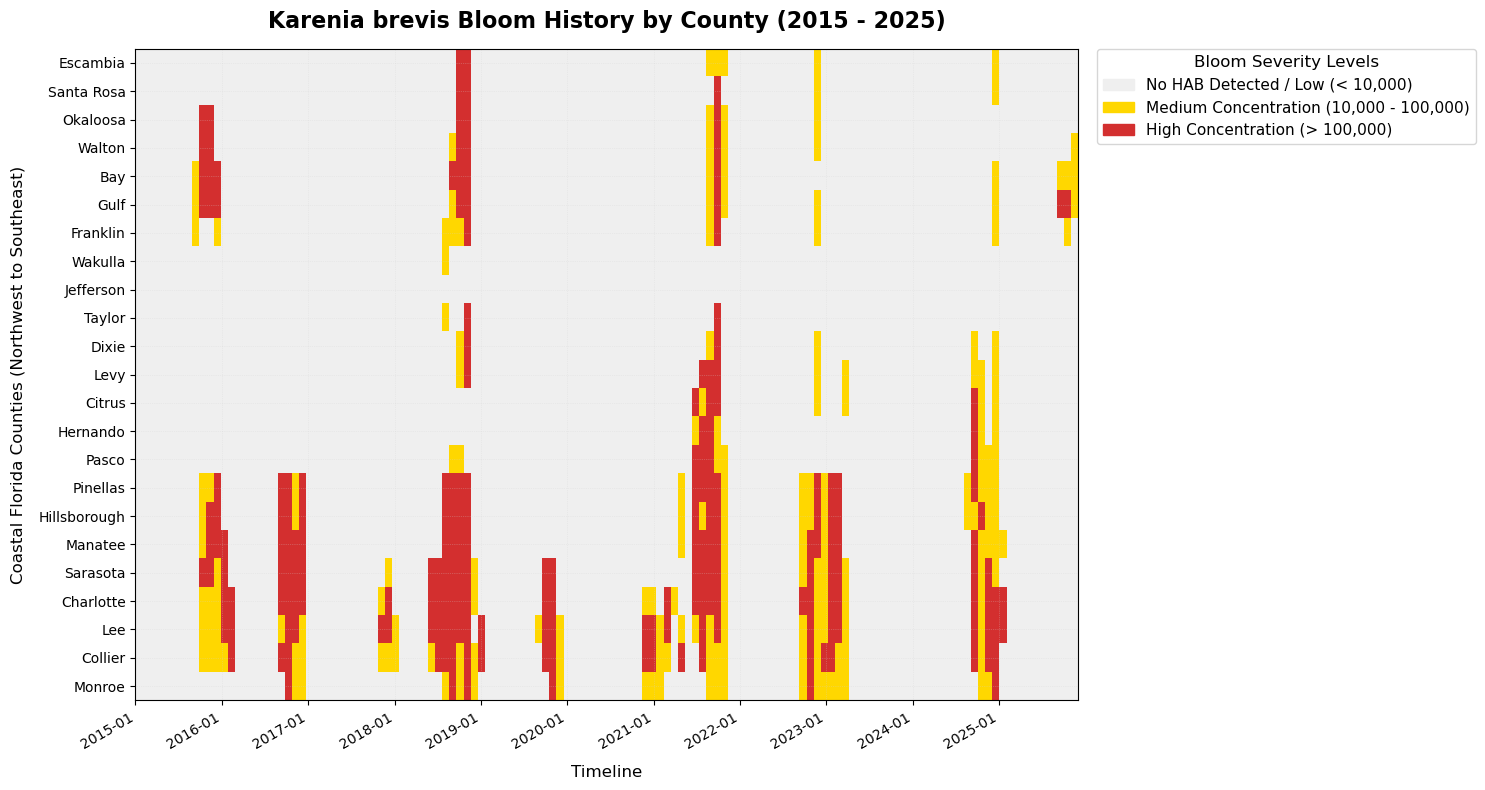

In [25]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

# ---------------------------------------------------
# CONFIGURATION & CONFIGURABLE TIME PARAMETERS
# ---------------------------------------------------
data_dir = "/home/jovyan/Gulf-ESR/data/unformatted/ecospace_ascii"
shp_path = "FloridaCountyBoundarieswithFDOTDistricts.shp"

start_year = 2015
end_year = 2025

target_counties = [
    "Escambia", "Santa Rosa", "Okaloosa", "Walton", "Bay", "Gulf",
    "Franklin", "Wakulla", "Jefferson", "Taylor", "Dixie", "Levy",
    "Citrus", "Hernando", "Pasco", "Pinellas", "Hillsborough",
    "Manatee", "Sarasota", "Charlotte", "Lee", "Collier",
    "Monroe"
]

# ---------------------------------------------------
# FUNCTION TO READ ASCII GRID
# ---------------------------------------------------
def read_asc(filepath):
    header = {}
    with open(filepath, "r") as f:
        header_lines = 0
        while header_lines < 6:
            line = f.readline()
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            key = parts[0].upper()
            value = parts[1]
            header[key] = float(value)
            header_lines += 1
            
        ncols = int(header["NCOLS"])
        nrows = int(header["NROWS"])
        xll = header["XLLCORNER"]
        yll = header["YLLCORNER"]
        cellsize = header["CELLSIZE"]
        nodata = header.get("NODATA_VALUE", -3.4e38)
        data = np.loadtxt(f)

    # Clean funky values and drop anything below threshold (> 9999 matches >= 10000)
    data[data <= -1e20] = np.nan
    data[data == nodata] = np.nan
    data[data <= 0] = np.nan
    data[data < 10000] = np.nan 
    data = np.ma.masked_invalid(data)

    extent = [xll, xll + ncols * cellsize, yll, yll + nrows * cellsize]
    return data, extent, header

# ---------------------------------------------------
# 1. LOAD & PREPARE COUNTIES SHAPEFILE
# ---------------------------------------------------
print("Loading and projecting county shapefile...")
gdf = gpd.read_file(shp_path)
gdf = gdf[gdf["NAME"].isin(target_counties)].copy()
gdf = gdf[["NAME", "geometry"]]

# FIX: Project to Florida GDL Albers (meters) instead of EPSG:4326 (degrees)
gdf = gdf.to_crs("EPSG:3086")

# ---------------------------------------------------
# 2. PRECOMPUTE SPATIAL LOOKUP INDEX (THE SECRET SAUCE)
# ---------------------------------------------------
print("Precomputing grid-to-county spatial mapping...")
sample_pattern = os.path.join(data_dir, "sdmTMB_log__*.asc")
sample_files = glob.glob(sample_pattern)
if not sample_files:
    raise FileNotFoundError(f"No ASCII (.asc) files found in {data_dir} to determine grid size.")

_, _, sample_header = read_asc(sample_files[0])
ncols = int(sample_header["NCOLS"])
nrows = int(sample_header["NROWS"])
xll = sample_header["XLLCORNER"]
yll = sample_header["YLLCORNER"]
cellsize = sample_header["CELLSIZE"]

# Generate grid coordinates (still in degrees based on your ASCII headers)
x_coords = xll + (np.arange(ncols) + 0.5) * cellsize
y_coords = yll + (nrows - 1 - np.arange(nrows) + 0.5) * cellsize
X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

flat_X = X_mesh.flatten()
flat_Y = Y_mesh.flatten()

# Initialize the GeoDataFrame in the grid's native degrees (4326)
grid_points_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(flat_X, flat_Y),
    crs="EPSG:4326"
)

# FIX: Project the grid points to match the Florida Albers projection (3086)
grid_points_gdf = grid_points_gdf.to_crs("EPSG:3086")

# Now the nearest-neighbor math runs flawlessly using true meter distances!
joined_lookup = gpd.sjoin_nearest(grid_points_gdf, gdf, how="left")
joined_lookup = joined_lookup.reset_index().drop_duplicates(subset='index').set_index('index')
pixel_county_map = joined_lookup["NAME"].values

# ---------------------------------------------------
# 3. GENERATE TIME-SERIES MATRIX CONTAINERS
# ---------------------------------------------------
# Establish complete Date Range at Monthly Resolution
date_range = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31", freq="MS")

# Master Hovmöller DataFrame: Rows = Counties (in geographic order), Columns = Timesteps
hovmoller_df = pd.DataFrame(np.nan, index=target_counties, columns=date_range)

# ---------------------------------------------------
# 4. LOOP AND PROCESS TIME SERIES DATA
# ---------------------------------------------------
print(f"Processing monthly timelines from {start_year} to {end_year}...")

for year in range(start_year, end_year + 1):
    pattern = os.path.join(data_dir, f"sdmTMB_log__{year}*.asc")
    files = sorted(glob.glob(pattern))
    
    # Organize found files by month digits
    monthly_files = {}
    for f in files:
        basename = os.path.basename(f)
        datestr = basename.split("__")[1].split(".")[0]
        month = int(datestr[4:6])
        monthly_files[month] = f
        
    for month in range(1, 13):
        current_timestep = pd.Timestamp(year=year, month=month, day=1)
        
        if month in monthly_files:
            # Read and filter thresholds natively
            data, _, _ = read_asc(monthly_files[month])
            flat_data = data.filled(np.nan).flatten()
            
            # Select only valid pixels (> 9999 values remaining after read filtering)
            valid_mask = ~np.isnan(flat_data)
            
            if np.any(valid_mask):
                valid_values = flat_data[valid_mask]
                valid_counties = pixel_county_map[valid_mask]
                
                # Pivot to temp pandas grouping for calculating clean averages
                temp_df = pd.DataFrame({'concentration': valid_values, 'county': valid_counties})
                temp_df = temp_df.dropna(subset=['county'])
                
                # Group and calculate the mean concentration
                monthly_county_means = temp_df.groupby('county')['concentration'].mean()
                
                # Fill the target matrix matching your desired layout
                for county, mean_val in monthly_county_means.items():
                    if county in hovmoller_df.index:
                        hovmoller_df.loc[county, current_timestep] = mean_val

# ---------------------------------------------------
# 5. PLOT THE HOVMÖLLER-LIKE HEATMAP (CATEGORICAL AUDIENCE EDIT)
# ---------------------------------------------------
print("Generating simplified categorical Hovmöller heatmap...")
fig, ax = plt.subplots(figsize=(15, 8))

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# 1. Define custom discrete colors for your active HAB categories
# Index 0: 10,000 to 100,000 (Yellow-ish Gold)
# Index 1: > 100,000 (Red)
category_colors = ['#FFD700', '#D32F2F'] 
cmap = mcolors.ListedColormap(category_colors)

# 2. Set a clean, neutral soft gray for all non-HAB or missing data values (NaNs)
# This keeps the plot from looking like an empty white grid
cmap.set_bad(color='#EFEFEF') 

# 3. Create hard boundaries to snap your data into discrete buckets
# Anything from 10k to 100k goes to Yellow; 100k to a massive upper ceiling goes to Red
boundaries = [10000, 100000, 1e12] 
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Translate dates to matplotlib friendly display coordinates
x_limits = mdates.date2num([date_range[0], date_range[-1]])
extent = [x_limits[0], x_limits[1], len(target_counties) - 0.5, -0.5]

# Plot using the categorical configurations
im = ax.imshow(
    hovmoller_df.values,
    extent=extent,
    aspect='auto',
    cmap=cmap,
    norm=norm
)

# Format the X-Axis Dates smoothly
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator(1)) # One tick mark per year
fig.autofmt_xdate()

# Format the Y-Axis Counties
ax.set_yticks(range(len(target_counties)))
ax.set_yticklabels(target_counties, fontsize=10)

# 4. Construct a clear, custom legend for a non-technical audience
legend_elements = [
    mpatches.Patch(color='#EFEFEF', edgecolor='none', label='No HAB Detected / Low (< 10,000)'),
    mpatches.Patch(color='#FFD700', edgecolor='none', label='Medium Concentration (10,000 - 100,000)'),
    mpatches.Patch(color='#D32F2F', edgecolor='none', label='High Concentration (> 100,000)')
]

ax.legend(
    handles=legend_elements, 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), # Places legend just outside the right edge of the plot
    borderaxespad=0.,
    fontsize=11,
    title="Bloom Severity Levels",
    title_fontsize=12
)

# Titles & Presentation Polish
ax.set_title(f"Karenia brevis Bloom History by County ({start_year} - {end_year})", fontsize=16, weight='bold', pad=15)
ax.set_xlabel("Timeline", fontsize=12, labelpad=10)
ax.set_ylabel("Coastal Florida Counties (Northwest to Southeast)", fontsize=12, labelpad=10)

# Subtle gridlines that sit behind the data blocks for alignment
ax.grid(True, which='both', color='#D3D3D3', linestyle=':', linewidth=0.5, alpha=0.5)

output_img = "hovmoller_categorical_hab.png"
plt.tight_layout()
fig.savefig(output_img, dpi=300, bbox_inches="tight")
print(f"Process complete! Clean categorical figure saved as {output_img}")
plt.show()

Loading and projecting county shapefile...
Precomputing grid-to-county spatial mapping...


/srv/conda/envs/notebook/lib/python3.12/site-packages/geopandas/array.py:407: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


Processing monthly timelines from 2005 to 2025...
Generating Hovmöller-like concentration heatmap...
Process complete! Figure saved as hovmoller_county_concentrations.png


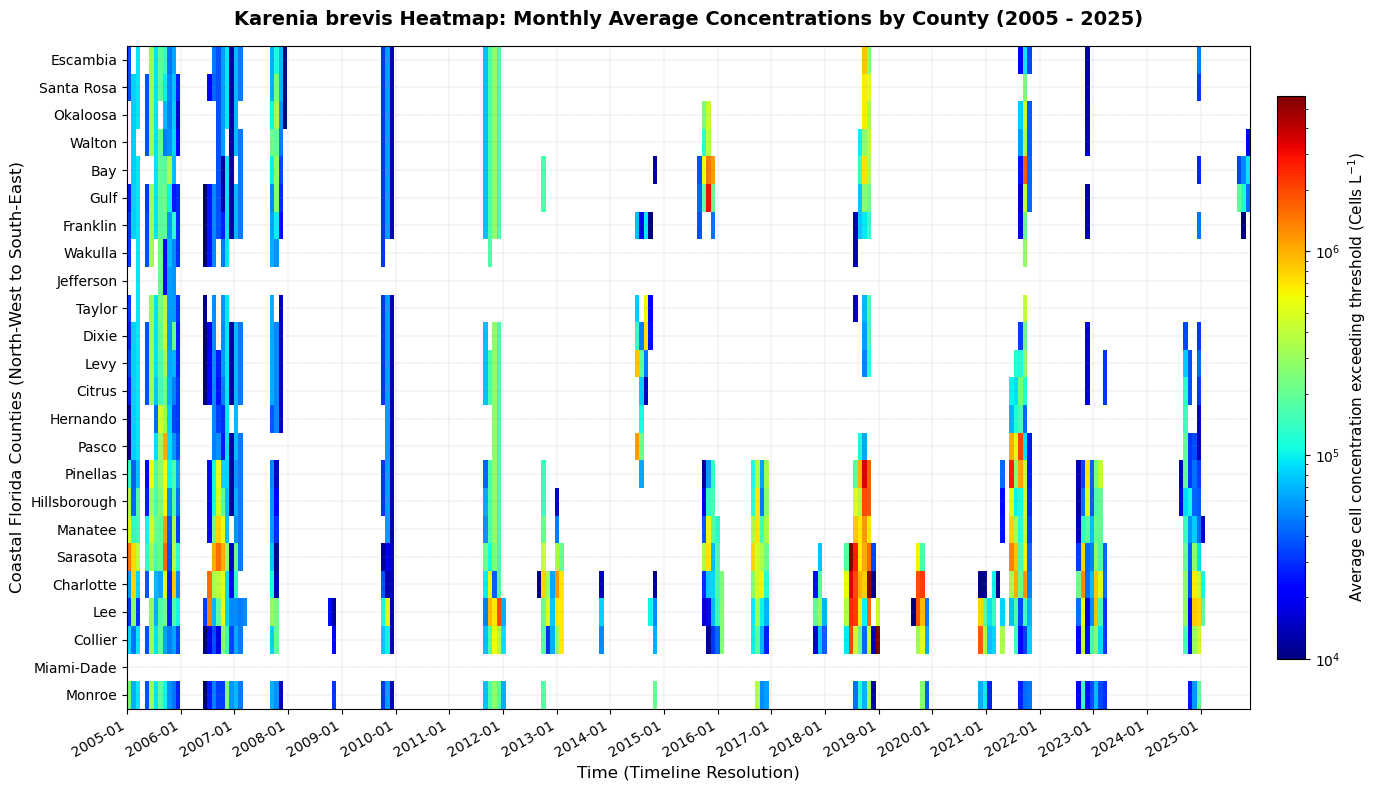

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

# ---------------------------------------------------
# CONFIGURATION & CONFIGURABLE TIME PARAMETERS
# ---------------------------------------------------
data_dir = "/home/jovyan/Gulf-ESR/data/unformatted/ecospace_ascii"
shp_path = "FloridaCountyBoundarieswithFDOTDistricts.shp"

start_year = 2005
end_year = 2025

target_counties = [
    "Escambia", "Santa Rosa", "Okaloosa", "Walton", "Bay", "Gulf",
    "Franklin", "Wakulla", "Jefferson", "Taylor", "Dixie", "Levy",
    "Citrus", "Hernando", "Pasco", "Pinellas", "Hillsborough",
    "Manatee", "Sarasota", "Charlotte", "Lee", "Collier",
    "Miami-Dade", "Monroe"
]

# ---------------------------------------------------
# FUNCTION TO READ ASCII GRID
# ---------------------------------------------------
def read_asc(filepath):
    header = {}
    with open(filepath, "r") as f:
        header_lines = 0
        while header_lines < 6:
            line = f.readline()
            if not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            key = parts[0].upper()
            value = parts[1]
            header[key] = float(value)
            header_lines += 1
            
        ncols = int(header["NCOLS"])
        nrows = int(header["NROWS"])
        xll = header["XLLCORNER"]
        yll = header["YLLCORNER"]
        cellsize = header["CELLSIZE"]
        nodata = header.get("NODATA_VALUE", -3.4e38)
        data = np.loadtxt(f)

    # Clean funky values and drop anything below threshold (> 9999 matches >= 10000)
    data[data <= -1e20] = np.nan
    data[data == nodata] = np.nan
    data[data <= 0] = np.nan
    data[data < 10000] = np.nan 
    data = np.ma.masked_invalid(data)

    extent = [xll, xll + ncols * cellsize, yll, yll + nrows * cellsize]
    return data, extent, header

# ---------------------------------------------------
# 1. LOAD & PREPARE COUNTIES SHAPEFILE
# ---------------------------------------------------
print("Loading and projecting county shapefile...")
gdf = gpd.read_file(shp_path)
gdf = gdf[gdf["NAME"].isin(target_counties)].copy()
gdf = gdf[["NAME", "geometry"]]
gdf = gdf.to_crs("EPSG:4326")

# ---------------------------------------------------
# 2. PRECOMPUTE SPATIAL LOOKUP INDEX (THE SECRET SAUCE)
# ---------------------------------------------------
print("Precomputing grid-to-county spatial mapping...")
# Find any available .asc file to extract the static grid architecture
sample_pattern = os.path.join(data_dir, "sdmTMB_log__*.asc")
sample_files = glob.glob(sample_pattern)
if not sample_files:
    raise FileNotFoundError(f"No ASCII (.asc) files found in {data_dir} to determine grid size.")

_, _, sample_header = read_asc(sample_files[0])
ncols = int(sample_header["NCOLS"])
nrows = int(sample_header["NROWS"])
xll = sample_header["XLLCORNER"]
yll = sample_header["YLLCORNER"]
cellsize = sample_header["CELLSIZE"]

# Generate precise cell center coordinates
x_coords = xll + (np.arange(ncols) + 0.5) * cellsize
# Invert Y coordinates because row 0 starts from the upper extent edge
y_coords = yll + (nrows - 1 - np.arange(nrows) + 0.5) * cellsize
X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

# Flatten grid mesh to assign each pixel to a county point map
flat_X = X_mesh.flatten()
flat_Y = Y_mesh.flatten()

grid_points_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(flat_X, flat_Y),
    crs="EPSG:4326"
)

# Find the nearest target coastal county for every single pixel in the grid
joined_lookup = gpd.sjoin_nearest(grid_points_gdf, gdf, how="left")
# Drop potential edge case ties (equidistant allocations) to preserve exact array dimensions
joined_lookup = joined_lookup.reset_index().drop_duplicates(subset='index').set_index('index')
pixel_county_map = joined_lookup["NAME"].values

# ---------------------------------------------------
# 3. GENERATE TIME-SERIES MATRIX CONTAINERS
# ---------------------------------------------------
# Establish complete Date Range at Monthly Resolution
date_range = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31", freq="MS")

# Master Hovmöller DataFrame: Rows = Counties (in geographic order), Columns = Timesteps
hovmoller_df = pd.DataFrame(np.nan, index=target_counties, columns=date_range)

# ---------------------------------------------------
# 4. LOOP AND PROCESS TIME SERIES DATA
# ---------------------------------------------------
print(f"Processing monthly timelines from {start_year} to {end_year}...")

for year in range(start_year, end_year + 1):
    pattern = os.path.join(data_dir, f"sdmTMB_log__{year}*.asc")
    files = sorted(glob.glob(pattern))
    
    # Organize found files by month digits
    monthly_files = {}
    for f in files:
        basename = os.path.basename(f)
        datestr = basename.split("__")[1].split(".")[0]
        month = int(datestr[4:6])
        monthly_files[month] = f
        
    for month in range(1, 13):
        current_timestep = pd.Timestamp(year=year, month=month, day=1)
        
        if month in monthly_files:
            # Read and filter thresholds natively
            data, _, _ = read_asc(monthly_files[month])
            flat_data = data.filled(np.nan).flatten()
            
            # Select only valid pixels (> 9999 values remaining after read filtering)
            valid_mask = ~np.isnan(flat_data)
            
            if np.any(valid_mask):
                valid_values = flat_data[valid_mask]
                valid_counties = pixel_county_map[valid_mask]
                
                # Pivot to temp pandas grouping for calculating clean averages
                temp_df = pd.DataFrame({'concentration': valid_values, 'county': valid_counties})
                temp_df = temp_df.dropna(subset=['county'])
                
                # Group and calculate the mean concentration
                monthly_county_means = temp_df.groupby('county')['concentration'].mean()
                
                # Fill the target matrix matching your desired layout
                for county, mean_val in monthly_county_means.items():
                    if county in hovmoller_df.index:
                        hovmoller_df.loc[county, current_timestep] = mean_val

# ---------------------------------------------------
# 5. PLOT THE HOVMÖLLER-LIKE HEATMAP
# ---------------------------------------------------
print("Generating Hovmöller-like concentration heatmap...")
fig, ax = plt.subplots(figsize=(15, 8))

# Dynamic value scaling with safety defaults
vmax_val = np.nanmax(hovmoller_df.values) if not np.isnan(hovmoller_df.values).all() else 1e6
vmin_val = 10000

# Translate dates to matplotlib friendly display coordinates
x_limits = mdates.date2num([date_range[0], date_range[-1]])
# Extent coordinates: [Left, Right, Bottom, Top]
# Setting bottom to len-0.5 and top to -0.5 mirrors Escambia at index 0 to the top row
extent = [x_limits[0], x_limits[1], len(target_counties) - 0.5, -0.5]

im = ax.imshow(
    hovmoller_df.values,
    extent=extent,
    aspect='auto',
    cmap='jet',
    norm=LogNorm(vmin=vmin_val, vmax=vmax_val)
)

# Format the X-Axis Dates smoothly
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator(1)) # Tick mark every year
fig.autofmt_xdate()

# Format the Y-Axis Counties
ax.set_yticks(range(len(target_counties)))
ax.set_yticklabels(target_counties, fontsize=10)

# Colorbar adjustments
cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.85)
cbar.set_label("Average cell concentration exceeding threshold (Cells L$^{-1}$)", fontsize=11)

# Titles & Annotations
ax.set_title(f"Karenia brevis Heatmap: Monthly Average Concentrations by County ({start_year} - {end_year})", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Time (Timeline Resolution)", fontsize=12)
ax.set_ylabel("Coastal Florida Counties (North-West to South-East)", fontsize=12)
ax.grid(True, which='both', color='grey', linestyle='--', linewidth=0.3, alpha=0.5)

output_img = "hovmoller_county_concentrations.png"
plt.tight_layout()
fig.savefig(output_img, dpi=300, bbox_inches="tight")
print(f"Process complete! Figure saved as {output_img}")
plt.show()